# IMT 573 - Final Examination


Points: 100

Name: Aneesh Karpoor

### Instructions

This is a take-home final examination. You may use your computer, books/articles, notes, course materials, etc., but all work must be your own! Please review the course policy on AI-based learning tools. References must be appropriately cited. Please justify your answers and show all work; a complete argument must be presented to obtain full credit. Before beginning this exam, please ensure you have access to data programming environments used in the course; this can be on your own personal computer or on shared infrastructure hosted by the university. 

1. Download the exam template notebook file from Canvas. Open exam notebook and supply your solutions to the exam by editing the notebook. 

2. Be sure the exam contains your full name. 

3. Be sure to include well-documented (e.g. commented) code chucks, figures, and clearly written text chunk explanations as necessary. Any figures should be clearly labeled and appropriately referenced within the text. Be sure that each visualization adds value to your written explanation; avoid redundancy -- you do not need four different visualizations of the same pattern.

4.  **Collaboration is not allowed on this exam. You may only speak with the course instructor about this material.**

5. All materials and resources that you use (with the exception of lecture slides) must be appropriately referenced within your assignment.

6. Remember partial credit will be awarded for each question for which a serious attempt at finding an answer has been shown. Students are **strongly** encouraged to attempt each question and to document their reasoning process even if they cannot find the correct answer. If you would like to include code to show this process, but it does not run without errors, you can do so by commenting out that code. 

7. When you have completed the assignment and have **checked** that your code both runs in the Console and compiles correctly rename the file to `YourLastName_YourFirstName.ipynb`, and submit BOTH your HTML and notebook files on Canvas.

### Statement of Compliance

You **must** include the a "signed" Statement of Compliance in your submission. The Compliance Statement is found below. You must include this text, word-for-word, in your final exam submission. Adding your name indicates you have read the statement and agree to its terms. Failure to do so will result in your exam **not** being accepted.

**Statement of Compliance**

I affirm that I have had no conversation regarding this exam with any persons other than the instructor. Further, I certify that the attached work represents my own thinking. Any information, concepts, or words that originate from other sources are cited in accordance with University of Washington guidelines as published in the Academic Code (available on the course website). I am aware of the serious consequences that result from improper discussions with others or from the improper citation of work that is not my own. 

(you name goes here as signature) 

(date of signature)




For this assignment, you'll need (at least) the following packages. If the package does not load, be sure it is properly installed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import logit, probit

### Problem 1

Points: 20

In this problem we will use data on infidelity, known as the Fair's Affairs dataset. The `Affairs` dataset is available as part of the `datasets` package in`statsmodels`. This data comes from a survey conducted by Psychology Today in 1969, see Greene (2003) and Fair (1978) for more information. 

The dataset contains various self-reported characteristics of 6366 participants, including how often the respondent engaged in extramarital sexual intercourse during the past year, as well as their gender, age, year married, whether they had children, their religiousness (on a 5-point scale, from 1=anti to 5=very), education, occupation (Hillingshead 7-point classification with reverse numbering), and a numeric self-rating of their marriage (from 1=very unhappy to 5=very happy).

(a) Describe the participants. Use descriptive, summarization, and exploratory techniques to describe the participants in the study. Tell us the average/mean of children count ? What is the average age of respondents? In your response comment on any ethical and privacy concerns you have with this dataset. 

In [2]:
affairs = sm.datasets.fair.load_pandas().data
print(sm.datasets.fair.NOTE)

::

    Number of observations: 6366
    Number of variables: 9
    Variable name definitions:

        rate_marriage   : How rate marriage, 1 = very poor, 2 = poor, 3 = fair,
                        4 = good, 5 = very good
        age             : Age
        yrs_married     : No. years married. Interval approximations. See
                        original paper for detailed explanation.
        children        : No. children
        religious       : How relgious, 1 = not, 2 = mildly, 3 = fairly,
                        4 = strongly
        educ            : Level of education, 9 = grade school, 12 = high
                        school, 14 = some college, 16 = college graduate,
                        17 = some graduate school, 20 = advanced degree
        occupation      : 1 = student, 2 = farming, agriculture; semi-skilled,
                        or unskilled worker; 3 = white-colloar; 4 = teacher
                        counselor social worker, nurse; artist, writers;
          

In [3]:
affairs.head()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


In [4]:
affairs.describe()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
count,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000
mean,4.109645,29.082862,9.009425,1.396874,2.426170,14.209865,3.424128,3.850141,0.705374
std,0.961430,6.847882,7.280120,1.433471,0.878369,2.178003,0.942399,1.346435,2.203374
min,1.000000,17.500000,0.500000,0.000000,1.000000,9.000000,1.000000,1.000000,0.000000
25%,4.000000,22.000000,2.500000,0.000000,2.000000,12.000000,3.000000,3.000000,0.000000
50%,4.000000,27.000000,6.000000,1.000000,2.000000,14.000000,3.000000,4.000000,0.000000
75%,5.000000,32.000000,16.500000,2.000000,3.000000,16.000000,4.000000,5.000000,0.484848
max,5.000000,42.000000,23.000000,5.500000,4.000000,20.000000,6.000000,6.000000,57.599991


First, let's look at the dataset at a high level. There are 6366 total observations and 9 variables (rate_marriage, age, yrs_married, children, religious, educ, occupation, occupation_husb, affairs). All of the variables are of float data type. There are no missing values in the dataset.

Next, let's look a bit deeper into the dataset. Using the .describe() function, I can get various summarized metrics regarding the data. Here are some of the key values:
- The average age of a participant in the dataset is ~29 years old.
- Average marriage rating from participants was a 4.1 / 5
- Average participant had ~1.4 children
- Average participant had a white-collar occupation (middle-class) or a teacher, counselor social worker, nurse; artist, writers; technician, skilled worker occupation.
- Average participant spent 0.7 (units unknown) of time in affairs

Lastly, let's look at the variables in more detail to see if there are any interesting insights that I can find.
- With the median marriage rating at 4/5 and the upper quartile at 5/5, that indicates that the marriage ratings of participants are generally skewed to the high ratings, so most people are happy with their marriages.
- The participants in the dataset are moderately educated, with an average education score of 14.2 which maps to "some college".
- Ages range from 17.5 - 42, which shows that the study is focused on young to middle-aged adults.
- There is a wide range of marriage lengths across participants, with an average marriage being around 9 years long but a standard deviation of 7.3 years. This is good for the dataset because it includes newly weds as well as couples who have been married for a while now.

There are some ethical and privacy concerns I have with this dataset since it is using personal data about private matters such as extramarital affairs. Even if the participants approved the use of this data for the study back in 1969, they would have had no idea that it would continue to be used by so many people later as a statsmodels public dataset.

(b) Suppose we want to explore the characteristics of participants who engage in extramarital sexual intercourse (i.e. affairs). Instead of modeling the number of affairs, consider the binary outcome - had an affair versus didn't have an affair. Create a new variable to capture this response variable of interest. What might the advantages and disadvantages of this approach to modeling the data be in this context?

In [5]:
affairs['affairs_binary'] = (affairs['affairs'] > 0).astype(int)
#print(affairs.head())

Advantages:
- Binary outcome is easier to make sense of compared to a decimal float value.
- Easier to do log regression models now thanks to a binary column.

Disadvantages:
- Now we can't tell the extent of the affairs, for example 1 affair and 10 affairs will be treated the same by this approach. While an affair is an affair, I think that for the sake of the study it is important to capture and analyze the range of affairs. 

(c) Use an appropriate regression model to explore the relationship between having an affair (binary) and other personal characteristics. Comment on which covariates seem to be predictive of having an affair and which do not.

In [6]:
log_reg_model = logit("affairs_binary ~ age + yrs_married + children + religious + educ + C(rate_marriage) + C(occupation) + C(occupation_husb)", data = affairs).fit()
print(log_reg_model.summary())

Optimization terminated successfully.
         Current function value: 0.541958
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:         affairs_binary   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6346
Method:                           MLE   Df Model:                           19
Date:                Mon, 01 Dec 2025   Pseudo R-squ.:                  0.1380
Time:                        02:00:20   Log-Likelihood:                -3450.1
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                2.105e-222
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     1.7854      0.609      2.932      0.003       0.

Note: In this scenario, I defined rate_marriage, occupation, and occupation_husb as categorical variables so I wrapped them with the C() tag. The rest are standard numeric variables. 

Based on the summary above, I immediately see that each of the rate_marriage categories (3, 4, 5) have a P-score less than 0.05 and negative coef values, therefore indicating that the higher rating a participant gave their marriage, this is usually a very good sign that there will be low chances for an affair. 
I also observe that occupation categories 5 and 6 (5 = managerial,administrative, business, 6 = professional with advanced degree) have a p-value less than 0.05 and high coef values, indicating that participants in these occupations had a much higher chance of having an affair. 

Some other covariates which have p-scores less than 0.05 are age, yrs_married, and religious. Age has a negative coef value, meaning that as age increases, the chances of affair decrease. Yrs_married has a slightly positive coef value, meaning that the longer a participant has been married, the higher the chances for an affair. Religious has a negative coef value, meaning that the more religious a participant is, the lesser the chances for affair.

Covariates that were not significant in predicting affairs were educ, children, occupation_husb, and occupations in categories 1-4, as all had p-values larger than 0.05. 

(d) Use a model selection procedure to obtain a "best" fit model. Is the model different from the full model you fit in part (c)? Which variables are included in the "best" fit model? [Hint: stepwise selection] 

In [7]:
# Only keep the significant variables in the model: rate_marriage, occupation, age, yrs_married, and religious
log_reg_model_best = logit("affairs_binary ~ age + yrs_married + religious + C(rate_marriage) + C(occupation)", data = affairs).fit()
print(log_reg_model_best.summary())

Optimization terminated successfully.
         Current function value: 0.542168
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:         affairs_binary   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6353
Method:                           MLE   Df Model:                           12
Date:                Mon, 01 Dec 2025   Pseudo R-squ.:                  0.1377
Time:                        02:00:20   Log-Likelihood:                -3451.4
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                1.980e-228
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   1.8896      0.548      3.449      0.001       0.816   

(e) Interpret the model parameters using the model from part (d).

Rate_marriage for categories 3 4 5 all have p-scores less than 0.05, and since their coef values are negative that means that people who rate their marriage higher than a 2 have much less odds of being involved in an affair. 
Once again, occupation for categories 5 and 6 have p-scores less than 0.05, and since their coef values are positive that means that there is a higher chance of affair in relationship when the occupation of participant falls under these two categories. 

Some other covariates which have p-scores less than 0.05 are age, yrs_married, and religious. Age has a negative coef value, meaning that as age increases, the chances of affair decrease. Yrs_married has a slightly positive coef value, meaning that the longer a participant has been married, the higher the chances for an affair. Religious has a negative coef value, meaning that the more religious a participant is, the lesser the chances for affair.

By finding this "best fit" model, I can highlight the covariates which are most significant in predicting affair outcomes.

(f) Create an artificial test dataset where martial rating varies from 1 to 5 randomly and all other variables are set to their means. Use this artificial dataset as your test dataset to obtain predicted probabilities of having an affair for case in the test data. Interpret your results and use a visualization to support your interpretation.

Skip

(g) Reflect on your analysis in this problem. After completing all the parts of this analysis what remaining and additional ethical and privacy conerns do you have?

One major ethical and privacy concern that I have already stated above is the fact that we are using real personal data involving participants affairs from a study many decades ago. The original participants of the study had no idea that their data would be used for academic purposes like this. Furthermore, by doing operations such as "optimizing" our affair predicition model, we are essentially simplifying the concept of real human problems into binary outcomes determined by a few variables. This is not fair to the real-world complexity that these participants experienced, and it is important to remember that these findings should only be analyzed at a high level.

### Problem 2

Points: 20

In this problem set, we will use some data from a sports context. The data is provided as part of the [Introduction to Statistial Learning with Applications in Python](https://www.statlearning.com/) textbook. It was taken from the StatLib library which is maintained at Carnegie Mellon University. The data provided is part of the data that was used in the 1988 ASA Graphics Section Poster Session. The salary data were originally from Sports Illustrated, April 20, 1987. The 1986 and career statistics were obtained from The 1987 Baseball Encyclopedia Update published by Collier Books, Macmillan Publishing Company, New York.

Following the directions below to load this data, `Hitters` directly from the `ISLP` python package. You may need to install the `ISLP` package before you can get started. In the Jupyter Hub you can open a terminal and use `pip install ISLP`. Next load the data as follows:

In [8]:
pip install ISLP


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
from ISLP import load_data
Hitters = load_data('Hitters')

Hitters.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


(a) Develop your own question to address in this analysis. Your question should be specific and measurable, and it should be able to be addressed through a basic analysis of the `Hitters` dataset. Hint: you will need to get to know this dataset and the variables available to formulate an appropriate question.

Do experienced/veteran players (10+ YOE) in the league make less errors than less experienced players? Analyze this trend across different levels of experience by using buckets of around 3 years each.

(b) Briefly summarize the dataset, describing what data exists and its basic properties. Comment on any issues that need to be resolved before you can proceed with your analysis.

In [10]:
#Hitters.describe()
#Hitters.shape
#Hitters.isna().sum()
print(Hitters.shape)
print(Hitters.dtypes)

(322, 20)
AtBat           int64
Hits            int64
HmRun           int64
Runs            int64
RBI             int64
Walks           int64
Years           int64
CAtBat          int64
CHits           int64
CHmRun          int64
CRuns           int64
CRBI            int64
CWalks          int64
League       category
Division     category
PutOuts         int64
Assists         int64
Errors          int64
Salary        float64
NewLeague    category
dtype: object


- There are 322 records in the dataset along with 20 variables
- I am assuming that the salary is listed in thousands of dollars.
- Most of the variables are of dtype int. League, Division, and NewLeague are all category dtype. Salary is the only variable that is float.


(c) Use the dataset to provide empirical evidence that addressed your question from (a). Discuss your results. Provide at least two visualizations to support your story.

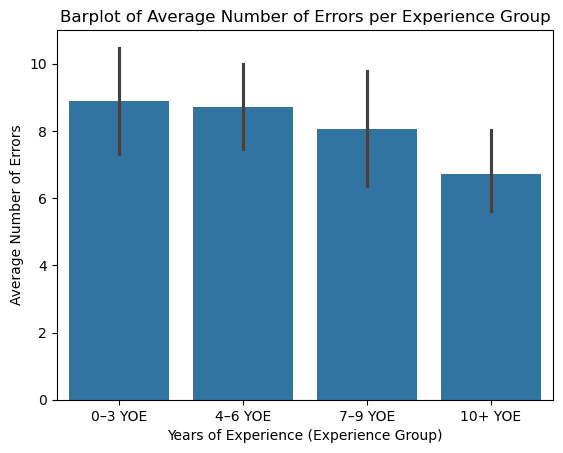

In [11]:
# Visualization 1: Histplot of Different YOE vs. Errors
# 0–3 years
exp_0_3 = Hitters[(Hitters['Years'] >= 0) & (Hitters['Years'] <= 3)].copy()
exp_0_3['ExperienceGroup'] = '0–3 YOE'

# 4–6 years
exp_4_6 = Hitters[(Hitters['Years'] >= 4) & (Hitters['Years'] <= 6)].copy()
exp_4_6['ExperienceGroup'] = '4–6 YOE'

# 7–9 years
exp_7_9 = Hitters[(Hitters['Years'] >= 7) & (Hitters['Years'] <= 9)].copy()
exp_7_9['ExperienceGroup'] = '7–9 YOE'

# 10+ years
exp_10_plus = Hitters[Hitters['Years'] >= 10].copy()
exp_10_plus['ExperienceGroup'] = '10+ YOE'

Hitters_exp = pd.concat([exp_0_3, exp_4_6, exp_7_9, exp_10_plus], ignore_index = True)

#print(Hitters_exp)

sns.barplot(data=Hitters_exp, x="ExperienceGroup", y = 'Errors')
plt.title("Barplot of Average Number of Errors per Experience Group")
plt.xlabel("Years of Experience (Experience Group)")
plt.ylabel("Average Number of Errors")
plt.show()

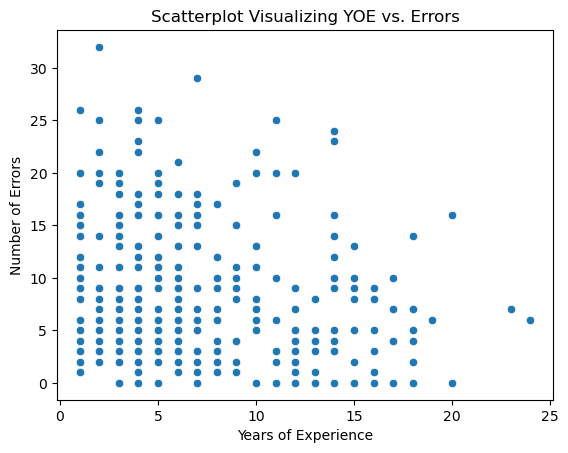

In [12]:
# Visualization 2: Scatterplot to Visualize YOE vs. Errors to observe "continuous" relationship rather than groups
sns.scatterplot(data=Hitters, x='Years', y='Errors')
plt.title("Scatterplot Visualizing YOE vs. Errors")
plt.xlabel("Years of Experience")
plt.ylabel("Number of Errors")
plt.show()

I was able to reach a conclusion for my initial guiding question which was: Do experienced/veteran players (10+ YOE) in the league make less errors than less experienced players?

I determined that yes, veteran players with 10+ YOE did contribute considerably less errors to their teams than their peers with lesser experience. This might sound like an obvious statement, but when I watch baseball it seems that all players are subject to making simple errors at all times. The findings from my plots demonstrate that as players gain more experience, then make less errors. In the first plot, there is an evident downward trend in the average number of errors in each experience group which matches my claim. Furthermore, in the second plot I see that once we cross 15+ YOE, the number of instances where a player commits many errors (more than 15) are far fewer. While there are objectively less data points the more you move across the x-axis, it is still helpful in answering my guiding question.

(d) Comment the questions (and answers) in this analysis. Were you able to answer all of these questions? Are all questions well defined? Is the data good enough to answer all these?

I was able to answer all of my guiding questions, which were clear and well defined. This allowed me to create simple yet effective visualizations to help answer my question. Initially I was planning on answering questions involving the salary and how that relates to YOE. However, there was a considerable amount of missing data with salary so I decided to go in a different direction in order to get the most accurate answer possible for my question. The data involving errors and years of experience was defintely good enough to answer the questions. 

One follow-up question that I have about the data is what are defined as errors? Is it only during pitching/fielding or during batting, or during all facets of the game? This matters because certain players might be used primarily as a hitter, but this would mean that they wouldn't be making many errors while pitching, if any. 

### Problem 3

Points: 20

In this problem, we will use data available in [Machine Learning with R by Brett Lantz](https://subscription.packtpub.com/search?query=machine%20learning%20r). This data was available in the public domain and a few version exist online. 

The data describe individual medical costs billed by health insurance. For each observation, there is information about:
- age: age of primary beneficiary of the insurance policy
- sex: the person's sex, measured here a binary gender
- bmi: body mass index, providing an understanding of body, weights that are relatively high or low relative to height, (kg / m ^ 2)
- children: number of children/dependents covered by health insurance
- smoker: smoking status of the primary beneficiary
- region: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.
- charges: medical costs billed by health insurance

In our analysis, we will be interested in the relationship between `charges` and the individual characteristics measured. 

In [13]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In our analysis, we will be interested in the relationship between charges and the individual characteristics measured.

(a) Examine the bivariate relationships present in the data. Briefly discuss notable results.

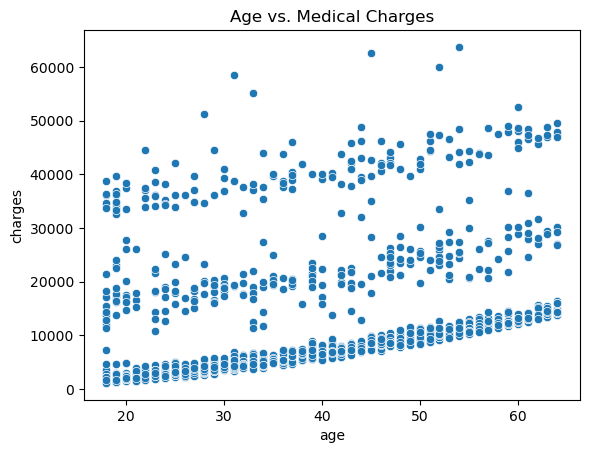

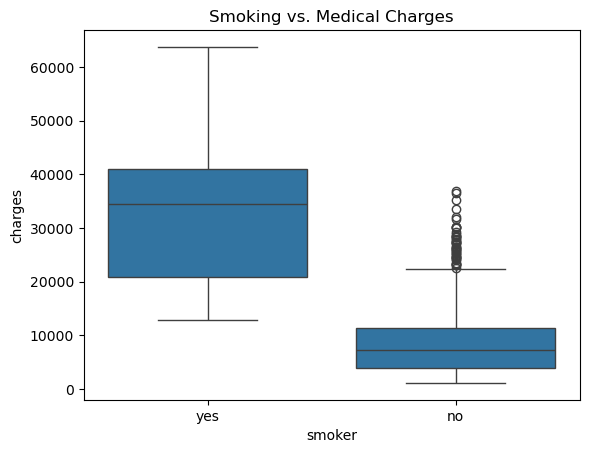

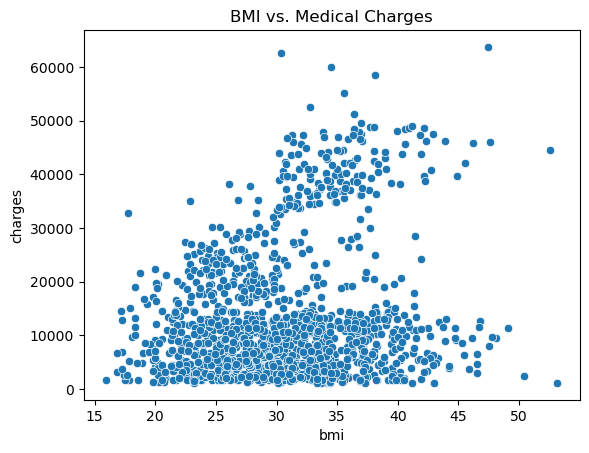

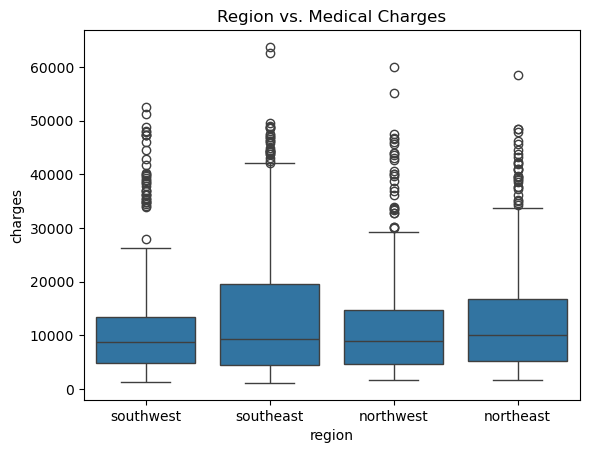

In [14]:
sns.scatterplot(data=df, x="age", y="charges")
plt.title("Age vs. Medical Charges")
plt.show()

sns.boxplot(data=df, x="smoker", y="charges")
plt.title("Smoking vs. Medical Charges")
plt.show()

sns.scatterplot(data=df, x="bmi", y="charges")
plt.title("BMI vs. Medical Charges")
plt.show()

sns.boxplot(data=df, x="region", y="charges")
plt.title("Region vs. Medical Charges")
plt.show()

The three plots above represent some of the notable trends found in this dataset.
- As age increases, the amount of charges generally increases too. This makes sense as people generally have more health problems as they age.
- People who do smoke tend to have higher medical charges, as smoking increases the risk of many medical issues.
- People with higher BMI scores tend to have higher medical charges, which makes sense because higher BMI means you are less healthy.
- The region that you live in doesn't play a huge role when it comes to medical charges.

(b) Fit a multiple linear regression model. How much variance in the medical costs(charges) does this variable- bmi explain?

In [15]:
multiple_reg_model = smf.ols("charges ~ age + sex + bmi + children + smoker + region", data = df).fit()

print(multiple_reg_model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Mon, 01 Dec 2025   Prob (F-statistic):               0.00
Time:                        02:00:24   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -1.194e+04    

Based on the results of the multiple linear regression above, it is evident that smoking, region SE and SW, age, BMI, and children all have a p value less than 0.05 making them significant variables in the model. When we then move to the coef value, we can see the actual amount of monetary impact that each variable has on the overall medical charges. While BMI does increase charges by around +339 dollars, this pales in comparison to how much a variable such as smoking impacts charges, which is +23,850 dollars. Smoking seems to explain a lot more variance in the model, and has a noticably large impact on the final charges.

(c) Evaluate the statistical assumptions in your regression analysis from part (b) by performing a basic analysis of model residuals and any unusual observations. Discuss any concerns you have about your model.

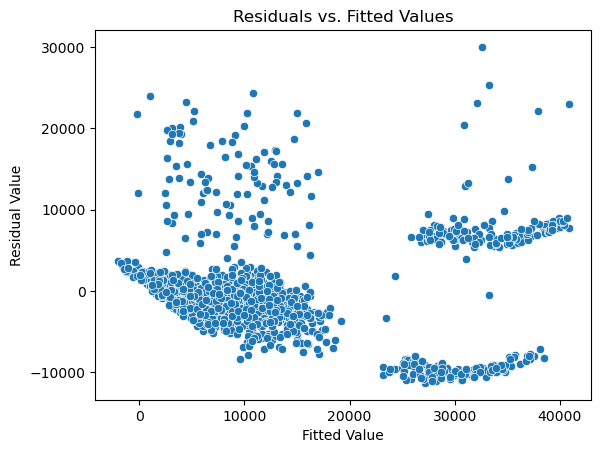

In [16]:
# Compare fitted and residual values
# Referenced statsmodels documentation for understanding residuals vs fitted: https://www.statsmodels.org/devel/examples/notebooks/generated/discrete_choice_example.html#Plot-fitted-values-vs-Pearson-residuals

residuals = multiple_reg_model.resid
fitted = multiple_reg_model.fittedvalues

sns.scatterplot(x=fitted, y=residuals)
plt.title("Residuals vs. Fitted Values")
plt.xlabel("Fitted Value")
plt.ylabel("Residual Value")
plt.show()

Referenced this YouTube video to understand plotting residuals vs fitted values: What Is A Residual Vs Fitted Plot? - The Friendly Statistician https://www.youtube.com/watch?v=MN3urJ3BhYs

In the plot above with the correctly fitted values and residuals from the regression model, I see three main clusters. This is concerning because ideally I should be seeing a random scattered plot, which tells me that the linear model I used is likely lacking complexity. It could benefit from using more variables that impact the final predicted medical charge. The distribution spread also changes a lot as the fitted value increases, which leads me to conclude that there is non-constant variance. The amount of variance / errors seems to increase a lot as the charges get higher.

(d) Use a stepwise model selection procedure of your choice to obtain a "best" fit model. Is the model different from the full model you fit in part (b)? If yes, how so?

In [17]:
# Remove the sex variable because this had a high p-value > 0.05
multiple_reg_model_2 = smf.ols("charges ~ age + bmi + children + smoker + region", data = df).fit()
print(multiple_reg_model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     572.7
Date:                Mon, 01 Dec 2025   Prob (F-statistic):               0.00
Time:                        02:00:24   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1330   BIC:                         2.715e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -1.199e+04    

The model ended up yielding very similar results to the previous model with a nearly identical r-squared value, so removing the sex variable did not make much of a difference.

EXTRA CREDIT (Max point: 2) : Fit a regression tree using the same covariates in your "best" fit model from part (d). Use cross validation to select the "best" tree. Compare the models from part (d) and (f) based on their performance. Which do you prefer? Be sure to justify your preference.

SKIP

### Problem 4

Points: 20

The Wisconsin Breast Cancer dataset is available on the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original). Our goal in this problem will be to predict whether observations (i.e. tumors) are malignant or benign. We will use the original dataset in this problem. 

(a) Obtain the data and load it into your programming environment by pulling it directly from the web (links provided below). (Do **not** download it and import it from a CSV file.) Give a brief description of the data. 

In [18]:
# Web location of data file
location = "http://archive.ics.uci.edu/ml/machine-learning-databases/"
dataframe = "breast-cancer-wisconsin/breast-cancer-wisconsin.data"
# Columns from website in specific order
columns = [
    "code_number",
    "clump_thickness",
    "uniform_cell_size",
    "uniform_cell_shape",
    "marginal_adhesion",
    "single_epithelial_cell_size",
    "bare_nuclei",
    "bland_chromatin",
    "normal_nucleoli",
    "mitoses",
    "target"
]
p4_data = pd.read_csv(location + dataframe, header = None)
p4_data.columns = columns

print(p4_data.head())
print(len(p4_data))

   code_number  clump_thickness  uniform_cell_size  uniform_cell_shape  \
0      1000025                5                  1                   1   
1      1002945                5                  4                   4   
2      1015425                3                  1                   1   
3      1016277                6                  8                   8   
4      1017023                4                  1                   1   

   marginal_adhesion  single_epithelial_cell_size bare_nuclei  \
0                  1                            2           1   
1                  5                            7          10   
2                  1                            2           2   
3                  1                            3           4   
4                  3                            2           1   

   bland_chromatin  normal_nucleoli  mitoses  target  
0                3                1        1       2  
1                3                2        1       2  

There are 699 records in the dataset, and 10 variables. The 11th variable is class, which is used as the "result" variable to show outcome. I've renamed this to target to avoid confusion later since "class" is used by python already.

(b) Investigate the data, ensuring that each variable is properly named and cast as the correct data type. Discuss any missing data.

In [19]:
print(p4_data.dtypes)

# Remove all rows with bare_nuclei = ?
p4_data = p4_data[p4_data["bare_nuclei"] != "?"]
p4_data["bare_nuclei"] = p4_data["bare_nuclei"].astype(int)
# Map 2 and 4 to 0 and 1 so we can use for log regression.
p4_data["target"] = p4_data["target"].map({2: 0, 4: 1})
print(len(p4_data))

code_number                     int64
clump_thickness                 int64
uniform_cell_size               int64
uniform_cell_shape              int64
marginal_adhesion               int64
single_epithelial_cell_size     int64
bare_nuclei                    object
bland_chromatin                 int64
normal_nucleoli                 int64
mitoses                         int64
target                          int64
dtype: object
683


- Only bare_nuclei has missing values according to the website. The missing values exist in the table as ?'s
- Class (renamed to target) has two options: a 2 indicates benign and 4 indicates malignant. This is our "result", which essentially is a binary value that I will use later for linear regression.
- All other variables are integer values except for bare_nuclei, which is of dtype Object.
- I converted the ?'s to NaN, and then turned the whole column into dtype int64.
- Now the dataset is ready for analysis

(c) Split the data into a training and test set such that a random 70\% of the observations are in the training set.

In [20]:
# Used code from previous problem set to split dataset into training and validation sets. 

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Set seed to create pseudo-randomness
np.random.seed(416)

# 70% train and 30% test
train_data, test_data = train_test_split(p4_data, test_size=0.3)

(d) Fit a ML model to predict whether tissue samples are malignant or benign. Then use your model to classify cases in your test set, which is the remaining 30% of the all the observations. Compute and discuss the resulting confusion matrix. Be sure to address which of the errors that are identified you consider most problematic in this context.

In [21]:
# Logistic Regression Model
log_reg_model_p4 = logit("target ~ clump_thickness + uniform_cell_size + uniform_cell_shape + marginal_adhesion + single_epithelial_cell_size + bare_nuclei + bland_chromatin + normal_nucleoli + mitoses", train_data).fit()
print(log_reg_model_p4.summary())

# Evaluate using test set. 0 = benign 1 = malignant
test_p4 = (log_reg_model_p4.predict(test_data) > 0.5).astype(int)
#print(test_p4)
cm_p4 = confusion_matrix(test_data['target'], test_p4)
print(cm_p4)


Optimization terminated successfully.
         Current function value: 0.056196
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                  478
Model:                          Logit   Df Residuals:                      468
Method:                           MLE   Df Model:                            9
Date:                Mon, 01 Dec 2025   Pseudo R-squ.:                  0.9137
Time:                        02:00:24   Log-Likelihood:                -26.862
converged:                       True   LL-Null:                       -311.12
Covariance Type:            nonrobust   LLR p-value:                1.194e-116
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                     -11.3646      1.820     -6.244      0.000  

Based on the results of my model, it is clear that there is a very strong fit, as evidenced by the 0.91 r-squared value. Certain predictors such  as clump_thickness, marginal_adhesion, and bare_nuclei all were statistically significant with p-scores less than 0.05. Since they all had positive coef values, this indicates that these predictors had a high influence on the final prediction between benign and malignant.

When looking at the test_data confusion matrix, 196 / 205 of the tests were correctly predicted true positive or true negative. The important error to call out is the 1 false negative, which is dangerous because a patient won't be able to begin the urgent care plan that is required for a malignant case. However, only one in the overall test is a pretty good rate. I would say that 8 false positives is still dangerous, since based on this prediction a patient might start receiving treatment that they don't even need, or they would be worried for no real reason.

### Problem 5

Points: 10

Please answer the questions below by writing a short response. 

(a) Describe three real-life applications in which **classification** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer. 

1. Diagnosing medical conditions: using predictors such as age, weight, smoking, exercise, family history, diet, etc. The goal of these applications are for predicitions, to predict whether a patient has a condition or not.
2. Classifying spam in messages or emails: using predictors such as use of key words, frequency of certain words, topics involved, email address, has attachments, attachment file types, etc. The goal of these applications are for predictions, to predict whether an email or message is spam or not. If it is spam, then the system or the user can decide to take some action.
3. Classifying days as high or low risk for fire: using predictors such as temperature, humidity, wind speed/direction, location/region, topography, vegetation, etc. The goal of these applications is to predict future fires in regions, so that necessary authorities can be prepared in advance and people living in the area can be alerted.

b) Describe three real-life applications in which **regression** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer. 

Note: The outcome needs to be a continuous numeric value, not a binary result.
1. Modeling fuel efficiency in cars. The response would be the MPG, and the predictors would be car make, engine type, driving style, car weight, etc. The goal for manufacturers here would be to use inference to determine which of the predictors have the largest impact on the end result which is the fuel efficiency MPG.
2. Regression can be useful in real-estate to determine property values using predictors such as price per sq ft, lot size in sq ft, # of bedrooms and bathrooms, year built, zip code / neighborhood, etc. The goal in this application is to most accurately predict the property value of a property based on all of these complex variables. Inference could also be used in real estate, for example to determine how much value a kitchen renovation would add to the property.
3. Predicting length of stay at hospital based on condition. The response would be number of days needed at hospital, and predictors such as condition, severity, age, vitals, hospital staffing/availability, etc would be useful here. The goal here would be for predictions to help the hospital best optimize their facility usage and staffing.


(c) What are the advantages and disadvantages of a very flexible (versus a less flexible) approach for regression or classification? Under what circumstances might a more flexible approach be preferred to a less flexible approach? When might a less flexible approach be preferred?

One advantage of a very flexible approach is that the model can better reflect a very complex relationship between variables. However, a resulting disadvantage is a high chance for overfitting and is dependent on having many variables.

An advantage of a less flexible approach is that it will generally be more straightforward to comprehend and there is a lower chance for overfitting. But a disadvantage of this approach is that these can yield far less accurate predictions as the model becomes increasingly complex.

If given a large dataset with many different variables to implement and focused on the best possible prediction accuracy, I would choose a more flexible approach. If given a smaller dataset that is generally linear I would choose a simpler, less flexible approach that focuses on being easy to comprehend (quickly understand which variables have the biggest impacts on outcome using coefs).

### Problem 6

Points: 10

Suppose we have a dataset with five predictors, $X_1 =$ GPA, $X_2 =$ IQ, $X_3 =$ Gender (1 for Female, and 0 for Male), $X_4 =$ Interaction between GPA and IQ, and $X_5 =$ Interaction between GPA and Gender. Note: the data here is limited as gender was collected as a binary variable.

The response is starting salary after graduation (in thousands of dollars). Suppose we use least squares to fit the model and get $\hat{\beta}_0=50, \hat{\beta}_1=20, \hat{\beta}_2=0.07, \hat{\beta}_3=35, \hat{\beta}_4=0.01$, and $\hat{\beta}_5=-10$. 

(a) Which answer is correct and why? <font color = red>[single choice question]

i. For a fixed value of IQ and GPA, males earn more on average than females.

ii. For a fixed value of IQ and GPA, females earn more on average than males.

iii. For a fixed value of IQ and GPA, males earn more on average than females provided that the GPA is high enough.

iv. For a fixed value of IQ and GPA, females earn more on average than males provided that the GPA is high enough.

Option 3. 

Looking at the coefficients in the model, females have a +35 coef working in their favor (X3 = 1 for female, 0 for male so doesn't affects males). However, they also have a -10 coef working against them due to the interaction between GPA and gender (only applies to females since X3 = 1). This means that for every increase of 1 in GPA for females, their salary is decreased by 10, but males don't face the same negative coef. Essentially, females will start at a better salary at lower GPAs, but as the GPA gets higher, males eventually overtake females in salary because they don't have the -10 coef working against them. 

(b) Write down the least square function and then predict the salary of a female with IQ of 110 and a GPA of 4.0.

Y = 50 + 20(GPA) + 0.07(IQ) + 35(Gender) + 0.01(GPA * IQ) - 10(GPA * Gender)

Y = 50 + 20(4) + 0.07(110) + 35(1) + 0.01(4 * 110) - 10(4 * 1)
Y = 50 + 80 + 7.7 + 35 + 4.4 - 40
Y = 137.1

Predicted salary = $137,100 for a female with IQ of 110 and a GPA of 4.0.

(c) True or false: Since the coefficient for the GPA/IQ interaction term is very small, there is little evidence of an interaction effect. Justify your answer.

False, just because the coefficient is very small that doesn't necessarily mean there is little evidence of an interaction effect. Rather, the important factor to consider is the p-value for each variable, if it is less than 0.05 then it is deemed statistically significant.

### Problem 7 - Extra Credit

Points: Max. 4

Suppose that $X_1, \ldots X_n$ form a random sample from a Poisson distribution for which the mean $\theta$ is unknown, $(\theta>0)$.

(a) Determine the MLE of $\theta$, assuming that at least one of the observed values is different from 0. Show your work.

(b) Show that the MLE of $\theta$ does not exists if every observed value is 0.

### Problem 8 - Extra Credit

Points: Max. 4

In this extra credit problem, you'll build a simple web scraper to collect and process text data. You'll write the code necessary to scrape lyrics for a desired artist. Your code should be structured such that one can easily execute your scraping functions for a given artist. There are three deliverables for this assignment:

1. A set of functions necessary for scraping the lyrics of a specific artist.
2. An example implementation of using your functions.
3. A file of example output from your notebook implementation.

The specific approach that you take to structuring your code is up to you, but the final output .csv data should have the following columns (each row is a song from an artist that you choose):

- Column 1: artist
- Column 2: album
- Column 3: song title
- Column 4: URL of song lyrics
- Column 5: song lyrics (all of the lyrics in one column)
- Column 6: number of words in the song

**Data Scraping:** The actual scraping of data should be supported by separate functions that accomplish these tasks:

1. Given an artist, identify all of their albums, songs, and links to songs.
2. Given a set of song links (from step 1), collect the lyrics to each song and store them in a data frame.

In order to do this, you'll need to understand the structure of your lyrics site. The site you use is up to you, but all of this information should be available on lyrics.com.

**Data Processing:**

Once you've scraped the data, you'll need to do some simple text analysis to generate your columns of interest (feel free to do this as part of step 2 above, the collection of lyrics for each song or as a separate step entirely). Recall you are aiming to count the number of words in each song.

**Example Implementation:**

You should demonstrate the implementation of your data scraping functions with a particular artist. To do this you can simply set an artist, and run your scraping functions. The way in which you choose to structure your functions is up to you, as long as the implementation and documentation is clear. One way in which we'll test this is changing the artist to confirm the flexibility of your implementation. 

It may look something like this:

In [22]:
# NOTE THIS CODE WILL NOT RUN 
# UNTIL YOU WRITE YOUR WEB SCRAPING FUNCTIONS

# Get songs
artist = 'Adele'
all_songs = get_songs(artist) 

# Get lyrics -- internally, you may want to another function in your library, such as get_lyrics()
lyrics = get_all_lyrics(songs)

# Save data -- this function should identify the name of the artist and use it in the .csv file it saves
save_lyrics(lyrics)

NameError: name 'get_songs' is not defined

(a) Write a function to get all the songs of a particular artist. 

(b) Write a function to get all the lyrics for a particular song. You may also want to write a function to get all the lyrics for a list of songs.  

(c) Choose a particular artist. Get all their songs. Get all the lyrics for their songs. Process the data so that you end up with a nice, tidy data structure as described in the instructions (i.e. the six columns listed above). Write out the data to a CSV file.  

(d) Produce one visualization of the data to aids in understanding the distribution of words in songs for a particular artist. Comment on what you find.  